# Serial Recall Accuracy

> Measure how often items are recalled in their original study order.

The serial recall accuracy curve (SRAC) reports the proportion of trials on which the item studied at each position is recalled in the matching output position. Unlike the serial position curve (which only tracks whether an item is recalled at all), SRAC requires the item to appear at the correct ordinal position in the recall sequence.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.srac import plot_srac
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
size = 3
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

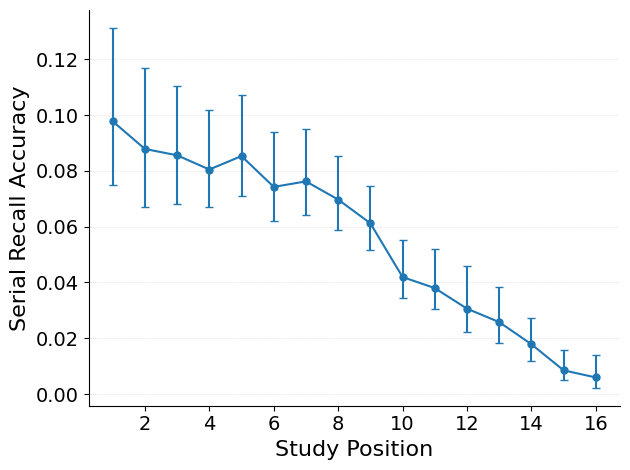

In [4]:
plot_srac(datasets=data, trial_masks=trial_mask, size=size, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows study position and the y-axis shows the probability of recalling that item at the correct output position. Key patterns:

- **High early accuracy**: items near the start of the list are often recalled in order, reflecting strong forward associations.
- **Declining accuracy**: accuracy typically drops across positions as order information degrades.
- **Comparison with SPC**: positions with high SPC but low SRAC are recalled but out of order.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `size` — maximum number of study positions a single item can occupy.
- `confidence_level` — confidence level for subject-wise error bars.
